# Fedora Editorial RAG — Exploration Notebook

Hands-on experimentation notebook for the mini-project covering both
the **Fedora Community Blog** and **Fedora Magazine** RAG pipelines.

**Sections:**
1. Dataset Overview (CommBlog + Magazine)
2. Quality Report Analysis (per publication)
3. Chunking Strategy Experiments
4. RAG Query Testing (CommBlog + Magazine)
5. Benchmark Results Visualization
6. Reference Article Tests (Good vs Bad)
7. Notes & Observations


---
## 0. Setup & Imports

In [1]:
import json
import os
import re
import subprocess
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Paths — dual-source structure ────────────────────────────────────────────
RAW_COMMBLOG     = Path('../data/raw/commblog')
RAW_MAGAZINE     = Path('../data/raw/magazine')
CLEANED_COMMBLOG = Path('../data/cleaned/commblog')
CLEANED_MAGAZINE = Path('../data/cleaned/magazine')
RESULTS_DIR      = Path('../results')

# Convenience aliases
RAW_DIR     = Path('../data/raw')
CLEANED_DIR = Path('../data/cleaned')

def count_files(path: Path, pattern: str) -> int:
    return len(list(path.glob(pattern))) if path.exists() else 0

print('Paths configured.')
print(f'  CommBlog raw     : {count_files(RAW_COMMBLOG, "*.json")} articles')
print(f'  Magazine raw     : {count_files(RAW_MAGAZINE, "*.json")} articles')
print(f'  CommBlog cleaned : {count_files(CLEANED_COMMBLOG, "*.md")} articles')
print(f'  Magazine cleaned : {count_files(CLEANED_MAGAZINE, "*.md")} articles')


Paths configured.
  CommBlog raw     : 1791 articles
  Magazine raw     : 1736 articles
  CommBlog cleaned : 1791 articles
  Magazine cleaned : 1736 articles


---
## 1. Dataset Overview (CommBlog + Magazine)

Explore what we fetched from both WordPress REST APIs.

In [2]:
# Load indexes from both sources
frames = []
for source_key, index_path in [
    ('commblog', RAW_COMMBLOG / 'index.json'),
    ('magazine',  RAW_MAGAZINE  / 'index.json'),
]:
    if index_path.exists():
        with open(index_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        tmp = pd.DataFrame(data)
        tmp['source'] = source_key
        frames.append(tmp)
    else:
        print(f'Index not found: {index_path} — run fetch_articles.py first.')

if frames:
    df = pd.concat(frames, ignore_index=True)
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    print(f'Total articles : {len(df)}')
    print(df.groupby('source').size().rename('count').to_string())
    print(f'Date range     : {df["date"].min().date()} to {df["date"].max().date()}')
    df.head(10)


Total articles : 3525
source
commblog    1790
magazine    1735
Date range     : 2013-07-04 to 2026-05-26


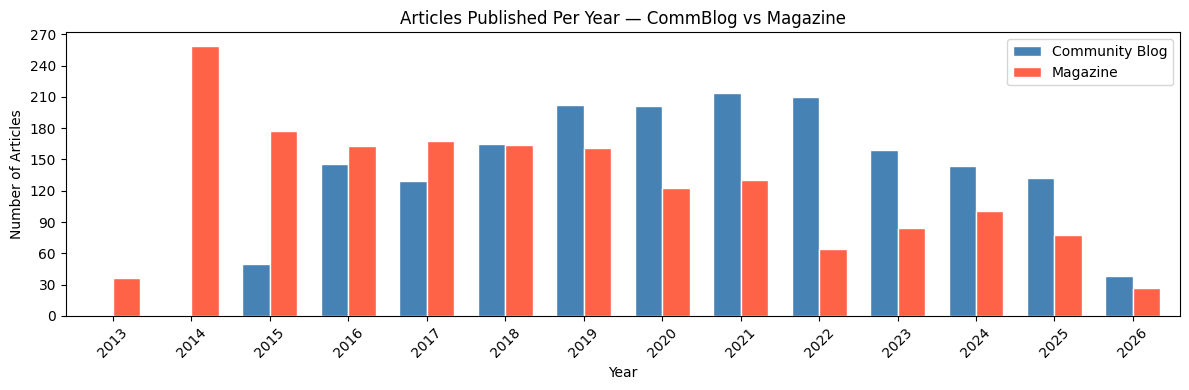

In [3]:
# Articles published per year — both sources side by side
if 'df' in dir() and len(df) > 0:
    yearly = df.groupby(['year', 'source']).size().unstack(fill_value=0)

    fig, ax = plt.subplots(figsize=(12, 4))
    yearly.plot(kind='bar', ax=ax,
                color={'commblog': 'steelblue', 'magazine': 'tomato'},
                edgecolor='white', width=0.7)
    ax.set_title('Articles Published Per Year — CommBlog vs Magazine')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Articles')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(['Community Blog', 'Magazine'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


---
## 2. Quality Report Analysis (per publication)

Review the output of `clean_dataset.py` for both CommBlog and Magazine.

In [4]:
# Load quality reports from both sources
report_frames = {}
for source_key, report_path in [
    ('commblog', CLEANED_COMMBLOG / 'quality_report.json'),
    ('magazine',  CLEANED_MAGAZINE  / 'quality_report.json'),
]:
    if report_path.exists():
        with open(report_path, 'r', encoding='utf-8') as f:
            report = json.load(f)
        report_frames[source_key] = pd.json_normalize(report)
        print(f'{source_key}: {len(report_frames[source_key])} articles in report')
    else:
        print(f'No report found for {source_key} — run clean_dataset.py first.')

# Use CommBlog as default for single-source cells below
qdf = report_frames.get('commblog', pd.DataFrame())
qdf.head()


commblog: 1791 articles in report
magazine: 1736 articles in report


,slug,title,source,quality.has_featured_image,quality.has_more_tag,quality.has_headings,quality.has_min_length,quality.has_title,quality.has_date,quality.passed
0,community-update-week-21-2026,Community Update &#8211; Week 21 2026,commblog,False,False,True,True,True,True,False
1,fedora-and-centos-scale-23x-2026,Fedora and CentOS @ SCALE 23x 2026,commblog,False,False,True,True,True,True,False
2,community-update-week-20,Community Update &#8211; Week 20,commblog,False,False,True,True,True,True,False
3,f44-election-nominations-now-open,F44 election nominations now open,commblog,False,False,False,True,True,True,False
4,community-update-week-19-2026,Community Update &#8211; Week 19 2026,commblog,False,False,True,True,True,True,False


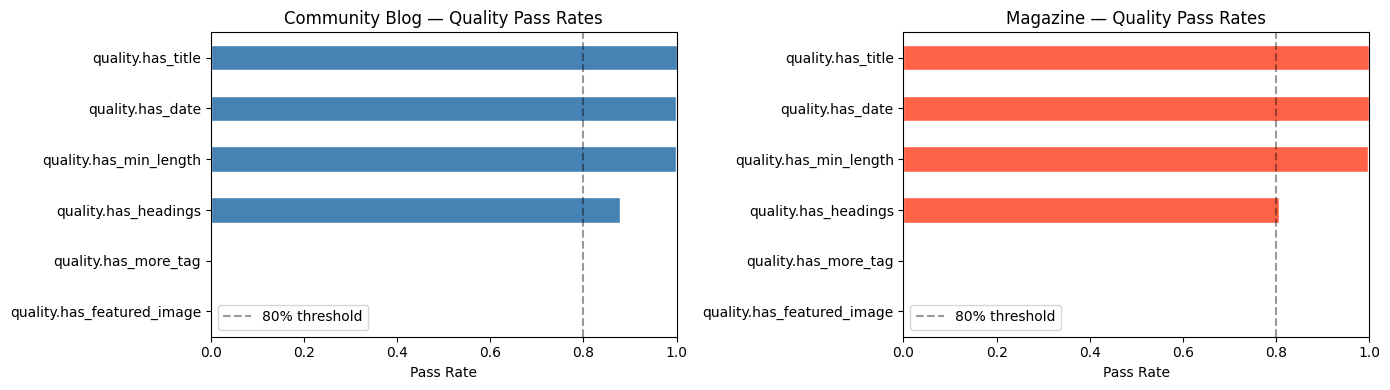

In [5]:
# Quality check pass rates — CommBlog vs Magazine side by side
if report_frames:
    fig, axes = plt.subplots(1, len(report_frames), figsize=(7 * len(report_frames), 4))
    if len(report_frames) == 1:
        axes = [axes]

    colors = {'commblog': 'steelblue', 'magazine': 'tomato'}
    labels = {'commblog': 'Community Blog', 'magazine': 'Magazine'}

    for ax, (source_key, qdf_src) in zip(axes, report_frames.items()):
        check_cols = [c for c in qdf_src.columns
                      if c.startswith('quality.') and c != 'quality.passed']
        pass_rates = qdf_src[check_cols].mean().sort_values()
        pass_rates.plot(kind='barh', ax=ax,
                        color=colors.get(source_key, 'steelblue'),
                        edgecolor='white')
        ax.set_title(f'{labels[source_key]} — Quality Pass Rates')
        ax.set_xlabel('Pass Rate')
        ax.set_xlim(0, 1)
        ax.axvline(0.8, color='black', linestyle='--', alpha=0.4, label='80% threshold')
        ax.legend()

    plt.tight_layout()
    plt.show()


In [6]:
# Articles that failed quality checks — per source
for source_key, qdf_src in report_frames.items():
    check_cols = [c for c in qdf_src.columns
                  if c.startswith('quality.') and c != 'quality.passed']
    failed = qdf_src[qdf_src['quality.passed'] == False][['slug', 'title'] + check_cols]
    print(f'\n{source_key} — Failed articles: {len(failed)}')
    if len(failed) > 0:
        display(failed.head(10))



commblog — Failed articles: 1791


,slug,title,quality.has_featured_image,quality.has_more_tag,quality.has_headings,quality.has_min_length,quality.has_title,quality.has_date
0,community-update-week-21-2026,Community Update &#8211; Week 21 2026,False,False,True,True,True,True
1,fedora-and-centos-scale-23x-2026,Fedora and CentOS @ SCALE 23x 2026,False,False,True,True,True,True
2,community-update-week-20,Community Update &#8211; Week 20,False,False,True,True,True,True
3,f44-election-nominations-now-open,F44 election nominations now open,False,False,False,True,True,True
4,community-update-week-19-2026,Community Update &#8211; Week 19 2026,False,False,True,True,True,True
5,community-update-week-18-2026,"Community Update &#8211; Week 18, 2026",False,False,True,True,True,True
6,join-us-for-podman-6-0-test-days-may-11-15-2026,Join Us for Podman 6.0 Test Days &#8211; May 1...,False,False,True,True,True,True
7,throwing-random-arguments-at-system-binaries-r...,Throwing Random Arguments at System Binaries: ...,False,False,True,True,True,True
8,community-update-week-17-2026,Community Update &#8211; Week 17 2026,False,False,True,True,True,True
9,fedora-verified-recognize-contributors,Fedora Verified: Help Shape a New Way to Recog...,False,False,True,True,True,True



magazine — Failed articles: 1736


,slug,title,quality.has_featured_image,quality.has_more_tag,quality.has_headings,quality.has_min_length,quality.has_title,quality.has_date
0,fedora-verified-what-does-the-community-think,Fedora Verified: What Does the Community Think?,False,False,True,True,True,True
1,how-fedora-is-responding-to-recent-kernel-vuln...,How Fedora is responding to recent Kernel vuln...,False,False,True,True,True,True
2,log-detective-in-packit,Log Detective in Packit,False,False,True,True,True,True
3,fedora-hummingbird-linux-taking-the-hummingbir...,Fedora Hummingbird: Taking the Hummingbird mod...,False,False,True,True,True,True
4,fedora-asahi-remix-44-is-now-available,Fedora Asahi Remix 44 is now available,False,False,False,True,True,True
5,whats-new-in-fedora-kde-plasma-desktop-44,What’s New in Fedora KDE Plasma Desktop 44,False,False,True,True,True,True
6,sealed-atomic-desktops-test-images,Sealed Fedora Atomic Desktop bootable containe...,False,False,True,True,True,True
7,whats-new-fedora-atomic-desktops-in-fedora-lin...,What’s New for Fedora Atomic Desktops in Fedor...,False,False,True,True,True,True
8,how-to-rebase-to-fedora-linux-44-on-silverblue,How to Rebase to Fedora Linux 44 on Silverblue,False,False,True,True,True,True
9,whats-new-fedora-workstation-44,What&#8217;s New in Fedora Workstation 44,False,False,True,True,True,True


---
## 3. Chunking Strategy Experiments

Test different chunk sizes to find the best balance for RAG retrieval.

In [7]:
def chunk_text(text: str, chunk_size: int, overlap: int) -> list[str]:
    """Simple token-approximation chunker (1 token ≈ 4 chars)."""
    words = text.split()
    chunks = []
    step = max(1, chunk_size - overlap)
    for i in range(0, len(words), step):
        chunk = ' '.join(words[i:i + chunk_size])
        if chunk:
            chunks.append(chunk)
    return chunks


# Load one sample article from each source
samples = {}
for source_key, cleaned_dir in [
    ('commblog', CLEANED_COMMBLOG),
    ('magazine',  CLEANED_MAGAZINE),
]:
    files = list(cleaned_dir.glob('*.md'))[:1]
    if files:
        samples[source_key] = files[0]
        text = files[0].read_text(encoding='utf-8')
        print(f'{source_key}: {files[0].name} ({len(text.split())} words)')
    else:
        print(f'{source_key}: no cleaned articles found yet.')


commblog: community-update-week-21-2026.md (751 words)
magazine: fedora-verified-what-does-the-community-think.md (524 words)


In [8]:
# Compare chunk counts across different chunk sizes — both sources
chunk_sizes = [128, 256, 512, 1024]
overlap = 64

for source_key, filepath in samples.items():
    sample_text = filepath.read_text(encoding='utf-8')
    print(f'\n{source_key}:')
    results = []
    for cs in chunk_sizes:
        chunks = chunk_text(sample_text, cs, overlap)
        avg_len = sum(len(c.split()) for c in chunks) / len(chunks) if chunks else 0
        results.append({'chunk_size': cs, 'num_chunks': len(chunks), 'avg_words': round(avg_len, 1)})
    chunk_df = pd.DataFrame(results)
    print(chunk_df.to_string(index=False))



commblog:
 chunk_size  num_chunks  avg_words
        128          12      119.8
        256           4      235.8
        512           2      407.5
       1024           1      751.0

magazine:
 chunk_size  num_chunks  avg_words
        128           9      109.3
        256           3      217.3
        512           2      294.0
       1024           1      524.0


---
## 4. RAG Query Testing (CommBlog + Magazine)

Run live queries against the RamaLama RAG pipeline for both publications.

> **Prerequisites:** RamaLama must be installed, models pulled, and RAG stores built:
> ```
> ramalama rag --chunk-size 256 data/cleaned/commblog quay.io/gtfrans2re/fedora-commblog-rag
> ramalama rag --chunk-size 256 data/cleaned/magazine  quay.io/gtfrans2re/fedora-magazine-rag
> ramalama rag --chunk-size 256 data/cleaned           quay.io/gtfrans2re/fedora-editorial-rag
> ```

In [9]:
# ── RamaLama RAG — Correct Workflow ──────────────────────────────────────────
#
# RamaLama RAG works in TWO steps:
#
#   Step 1 — Build: convert your corpus into an OCI image (vector store)
#     ramalama rag --chunk-size 256 <corpus_dir> <oci_image>
#
#   Step 2 — Run: query a model using that OCI image
#     ramalama run --rag <oci_image> <model>
#
# OR use ad-hoc mode (no OCI image needed, good for quick testing):
#     ramalama run --nocontainer --rag <corpus_dir> <model>

import subprocess
import os

# ── OCI images — one per publication + one combined ───────────────────────────
RAG_IMAGES = {
    'commblog': 'quay.io/gtfrans2re/fedora-commblog-rag',
    'magazine':  'quay.io/gtfrans2re/fedora-magazine-rag',
    'both':      'quay.io/gtfrans2re/fedora-editorial-rag',
}

CORPUS_DIRS = {
    'commblog': '../data/cleaned/commblog',
    'magazine':  '../data/cleaned/magazine',
    'both':      '../data/cleaned',
}

# ── Select active publication ─────────────────────────────────────────────────
# Change this to 'magazine' or 'both' as needed
ACTIVE_SOURCE = 'commblog'

RAG_IMAGE  = RAG_IMAGES[ACTIVE_SOURCE]
CORPUS_DIR = CORPUS_DIRS[ACTIVE_SOURCE]


def build_rag_store(
    corpus_dir: str = CORPUS_DIR,
    image: str = RAG_IMAGE,
    chunk_size: int = 256,
) -> bool:
    """
    Step 1 — Build the RAG vector store from the corpus.
    chunk_size=256 stays safely under the 512-token embedder batch limit.
    """
    print(f'Building RAG store from : {corpus_dir}')
    print(f'Target OCI image        : {image}')
    print(f'Chunk size              : {chunk_size} tokens')
    print('This may take a few minutes...\n')
    cmd = ['ramalama', 'rag', '--chunk-size', str(chunk_size), corpus_dir, image]
    result = subprocess.run(cmd, text=True, timeout=600)
    if result.returncode != 0:
        print(f'ERROR: RAG store build failed (exit code {result.returncode})')
        return False
    print(f'RAG store built successfully: {image}')
    return True


def query_rag_interactive(model: str, image: str = RAG_IMAGE) -> None:
    """Step 2 — Interactive session against the RAG OCI image."""
    print(f'Launching interactive RAG session...')
    print(f'  Model : {model}')
    print(f'  RAG   : {image}')
    print('Type your query at the prompt. Ctrl+D to exit.\n')
    subprocess.run(['ramalama', 'run', '--rag', image, model])


def query_rag_adhoc(model: str, prompt: str, corpus_dir: str = CORPUS_DIR) -> str:
    """Ad-hoc query — no OCI image needed. Pipes prompt via stdin."""
    cmd = ['ramalama', 'run', '--nocontainer', '--rag', corpus_dir, model]
    result = subprocess.run(
        cmd, input=prompt, capture_output=True, text=True, timeout=180
    )
    if result.returncode != 0:
        return f'ERROR: {result.stderr.strip()}'
    return result.stdout.strip()


print(f'RamaLama RAG helpers loaded.')
print(f'  Active source : {ACTIVE_SOURCE}')
print(f'  RAG image     : {RAG_IMAGE}')
print(f'  Corpus dir    : {CORPUS_DIR}')
print(f'  To switch publication, change ACTIVE_SOURCE above and re-run this cell.')


RamaLama RAG helpers loaded.
  Active source : commblog
  RAG image     : quay.io/gtfrans2re/fedora-commblog-rag
  Corpus dir    : ../data/cleaned/commblog
  To switch publication, change ACTIVE_SOURCE above and re-run this cell.


In [10]:
# ── Step 1: Build the RAG vector stores (run once per source) ────────────────
# Requires: Podman running + data/cleaned/commblog/ and data/cleaned/magazine/ populated
#
# Uncomment whichever store(s) you want to build:

# CommBlog only
# build_rag_store('../data/cleaned/commblog', 'quay.io/gtfrans2re/fedora-commblog-rag')

# Magazine only
# build_rag_store('../data/cleaned/magazine', 'quay.io/gtfrans2re/fedora-magazine-rag')

# Combined (both publications)
# build_rag_store('../data/cleaned', 'quay.io/gtfrans2re/fedora-editorial-rag')


In [11]:
# ── Step 2a: Interactive session (full RAG pipeline) ─────────────────────────
# Requires Step 1 (build_rag_store) to have completed successfully first.
#
# IMPORTANT: Use HuggingFace model format — ollama:// is deprecated in ramalama.
# From your pulled models (ramalama list), use:
#   'hf://Qwen/Qwen3-4B-GGUF'             instead of 'qwen2.5:7b'
#   'hf://Qwen/Qwen3-1.7B-GGUF'           instead of 'smollm2:1.7b'
#   'hf://ggml-org/gemma-3-4b-it-GGUF'    (already correct)
#   'hf://instructlab/granite-7b-lab-GGUF/granite-7b-lab-Q4_K_M.gguf'  for Granite
#
# Uncomment when ready:

# query_rag_interactive('hf://Qwen/Qwen3-4B-GGUF')


In [21]:
# ── Step 2b: Ad-hoc query (quick test, no OCI image needed) ──────────────────
# Change ACTIVE_SOURCE in the helpers cell above to switch publications.

MODEL = 'hf://Qwen/Qwen3-4B-GGUF'

PROMPTS = {
    'commblog': 'What tone should a Fedora Community Blog article use?',
    'magazine':  'What are the required elements for a Fedora Magazine article?',
    'both':      'What editorial standards are shared between the Fedora Community Blog and Fedora Magazine?',
}

PROMPT = PROMPTS[ACTIVE_SOURCE]
print(f'Active source : {ACTIVE_SOURCE}')
print(f'Prompt        : {PROMPT}')

# Uncomment to run:
# response = query_rag_adhoc(MODEL, PROMPT)
# print(response)

Active source : commblog
Prompt        : What tone should a Fedora Community Blog article use?
ERROR: usage: ramalama [-h] [-v] [--debug | --quiet] [--dryrun]
                [--engine {podman,docker}] [--nocontainer]
                [--runtime {llama.cpp,mlx,vllm}] [--store STORE]
                {run,serve,bench,benchmark,perplexity,convert,benchmarks,chat,containers,ps,help,info,inspect,list,ls,login,logout,pull,push,rm,sandbox,stop,version,daemon} ...
ramalama: error: unrecognized arguments: --nocontainer


In [13]:
# ── Side-by-side model comparison (ad-hoc) ───────────────────────────────────
MODELS = [
    'hf://Qwen/Qwen3-4B-GGUF',
    'hf://Qwen/Qwen3-1.7B-GGUF',
    'hf://ggml-org/gemma-3-4b-it-GGUF',
    'hf://instructlab/granite-7b-lab-GGUF/granite-7b-lab-Q4_K_M.gguf',
]

# Test prompts per publication
COMPARISON_PROMPTS = {
    'commblog': 'What are the required elements for a Fedora Community Blog article?',
    'magazine':  'What are the required elements for a Fedora Magazine article?',
    'both':      'How do the editorial standards of the Fedora Community Blog and Fedora Magazine differ?',
}
TEST_PROMPT = COMPARISON_PROMPTS[ACTIVE_SOURCE]

# Uncomment to run (takes time — one model at a time):
# for model in MODELS:
#     print(f'\n=== {model} ===')
#     print(query_rag_adhoc(model, TEST_PROMPT))


---
## 5. Benchmark Results Visualization

Visualize results from `scripts/benchmark.py`.

In [22]:
# Load the most recent benchmark result
result_files = sorted(RESULTS_DIR.glob('benchmark_*.json')) if RESULTS_DIR.exists() else []

if not result_files:
    print('No benchmark results found yet. Run scripts/benchmark.py first.')
else:
    latest = result_files[-1]
    with open(latest, 'r', encoding='utf-8') as f:
        bench = json.load(f)
    print(f'Loaded: {latest.name}')
    print(f'Models tested: {[m["label"] for m in bench["models"]]}')


Loaded: benchmark_20260523_121427.json
Models tested: ['Qwen 2.5 7B', 'SmolLM2 1.7B', 'Gemma 3 4B', 'Granite 3.3 8B']


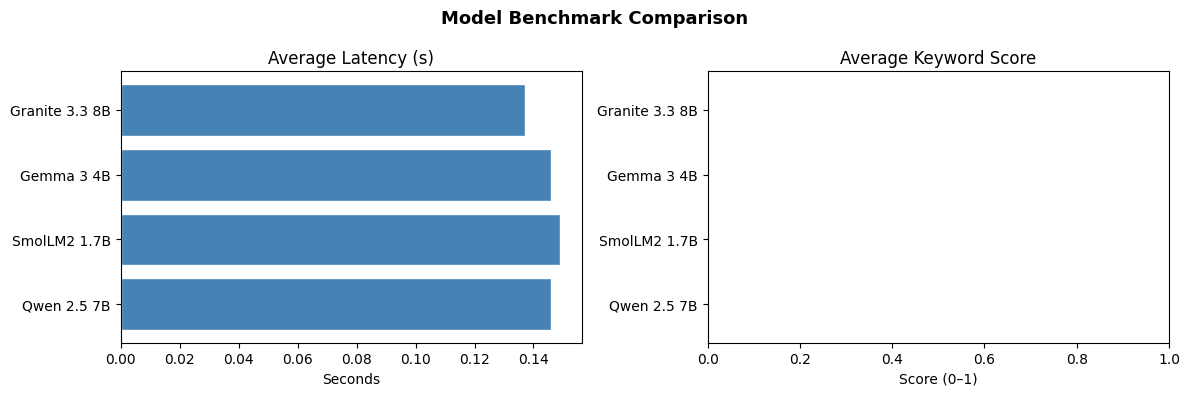

In [23]:
# Plot: average latency vs keyword score per model
if result_files:
    labels   = [m['label'] for m in bench['models']]
    latency  = [m['avg_latency_s'] for m in bench['models']]
    scores   = [m['avg_keyword_score'] for m in bench['models']]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.barh(labels, latency, color='steelblue', edgecolor='white')
    ax1.set_title('Average Latency (s)')
    ax1.set_xlabel('Seconds')

    ax2.barh(labels, scores, color='mediumseagreen', edgecolor='white')
    ax2.set_title('Average Keyword Score')
    ax2.set_xlabel('Score (0–1)')
    ax2.set_xlim(0, 1)

    plt.suptitle('Model Benchmark Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


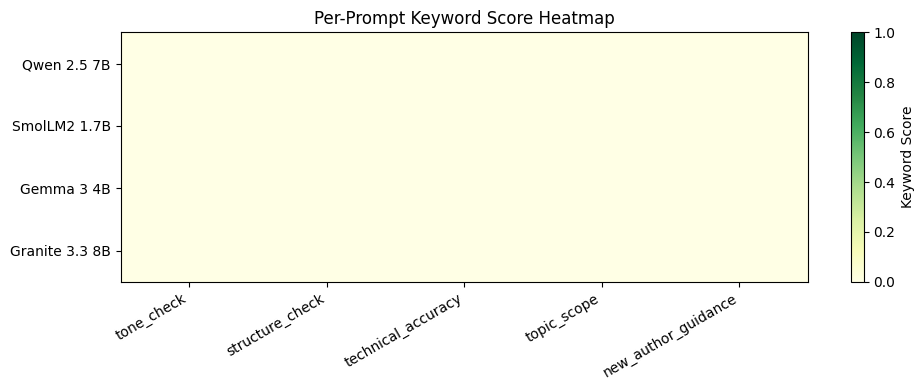

In [24]:
# Per-prompt breakdown heatmap
if result_files:
    prompt_ids = [p['id'] for p in bench['models'][0]['prompts']]
    heatmap_data = [
        [p['keyword_score'] for p in m['prompts']]
        for m in bench['models']
    ]
    hm_df = pd.DataFrame(heatmap_data, index=labels, columns=prompt_ids)

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(hm_df.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(prompt_ids)))
    ax.set_xticklabels(prompt_ids, rotation=30, ha='right')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    plt.colorbar(im, ax=ax, label='Keyword Score')
    ax.set_title('Per-Prompt Keyword Score Heatmap')
    plt.tight_layout()
    plt.show()


---
## 6. Reference Article Tests (Good vs Bad)

Test the RAG model against the known good and bad articles from the project spec.
The model should confirm good articles meet standards and flag specific issues in bad ones.

**Good articles** — should pass editorial review:
- https://communityblog.fedoraproject.org/f44-election-nominations-now-open/
- https://communityblog.fedoraproject.org/code-of-conduct-report-2025/
- https://communityblog.fedoraproject.org/throwing-random-arguments-at-system-binaries-real-segfaults-vs-ticket-noise/
- https://communityblog.fedoraproject.org/the-forge-is-our-new-home/
- https://communityblog.fedoraproject.org/two-shell-functions-to-simplify-pagure-pull-request-reviews/

**Bad articles** — should flag specific issues:
- https://communityblog.fedoraproject.org/fedora-and-centos-scale-23x-2026/ — missing featured image
- https://communityblog.fedoraproject.org/community-update-week-20/ — missing `<!--more-->` tag


In [25]:
# ── Good article tests ────────────────────────────────────────────────────────
# Paste the article body where indicated and run.
# The model should confirm the article meets CommBlog editorial standards.

GOOD_TESTS = [
    {
        'label': 'Good — F44 Election Nominations Now Open',
        'url':   'https://communityblog.fedoraproject.org/f44-election-nominations-now-open/',
        'prompt': (
            'Review this Fedora Community Blog article. Does it meet editorial standards '
            'for tone, structure, featured image, use of the --more-- tag, headers, '
            'tags, and category? Flag any issues or confirm it is ready to publish.\n\n'
            'Title: F44 Election Nominations Now Open\n'
            'URL: https://communityblog.fedoraproject.org/f44-election-nominations-now-open/\n'
            '[paste article body here]'
        ),
    },
    {
        'label': 'Good — Code of Conduct Report 2025',
        'url':   'https://communityblog.fedoraproject.org/code-of-conduct-report-2025/',
        'prompt': (
            'Review this Fedora Community Blog article. Does it meet editorial standards '
            'for tone, structure, featured image, use of the --more-- tag, headers, '
            'tags, and category? Flag any issues or confirm it is ready to publish.\n\n'
            'Title: Code of Conduct Report 2025\n'
            'URL: https://communityblog.fedoraproject.org/code-of-conduct-report-2025/\n'
            '[paste article body here]'
        ),
    },
    {
        'label': 'Good — Throwing Random Arguments at System Binaries',
        'url':   'https://communityblog.fedoraproject.org/throwing-random-arguments-at-system-binaries-real-segfaults-vs-ticket-noise/',
        'prompt': (
            'Review this Fedora Community Blog article. Does it meet editorial standards '
            'for tone, structure, featured image, use of the --more-- tag, headers, '
            'tags, and category? Flag any issues or confirm it is ready to publish.\n\n'
            'Title: Throwing Random Arguments at System Binaries\n'
            '[paste article body here]'
        ),
    },
    {
        'label': 'Good — The Forge Is Our New Home',
        'url':   'https://communityblog.fedoraproject.org/the-forge-is-our-new-home/',
        'prompt': (
            'Review this Fedora Community Blog article. Does it meet editorial standards '
            'for tone, structure, featured image, use of the --more-- tag, headers, '
            'tags, and category? Flag any issues or confirm it is ready to publish.\n\n'
            'Title: The Forge Is Our New Home\n'
            '[paste article body here]'
        ),
    },
    {
        'label': 'Good — Two Shell Functions to Simplify Pagure Pull Request Reviews',
        'url':   'https://communityblog.fedoraproject.org/two-shell-functions-to-simplify-pagure-pull-request-reviews/',
        'prompt': (
            'Review this Fedora Community Blog article. Does it meet editorial standards '
            'for tone, structure, featured image, use of the --more-- tag, headers, '
            'tags, and category? Flag any issues or confirm it is ready to publish.\n\n'
            'Title: Two Shell Functions to Simplify Pagure Pull Request Reviews\n'
            '[paste article body here]'
        ),
    },
]

MODEL = 'hf://Qwen/Qwen3-4B-GGUF'

# Uncomment to run one at a time:
# response = query_rag_adhoc(MODEL, GOOD_TESTS[0]['prompt'])
# print(response)


ERROR: usage: ramalama [-h] [-v] [--debug | --quiet] [--dryrun]
                [--engine {podman,docker}] [--nocontainer]
                [--runtime {llama.cpp,mlx,vllm}] [--store STORE]
                {run,serve,bench,benchmark,perplexity,convert,benchmarks,chat,containers,ps,help,info,inspect,list,ls,login,logout,pull,push,rm,sandbox,stop,version,daemon} ...
ramalama: error: unrecognized arguments: --nocontainer


In [18]:
# ── Bad article tests ─────────────────────────────────────────────────────────
# The model should flag the specific editorial issues in these articles.

BAD_TESTS = [
    {
        'label':    'Bad — Missing featured image',
        'url':      'https://communityblog.fedoraproject.org/fedora-and-centos-scale-23x-2026/',
        'expected': 'missing featured image',
        'prompt': (
            'This Fedora Community Blog article was published without a featured image.\n'
            'According to the CommBlog editorial guidelines:\n'
            '1. Is a featured image required or optional?\n'
            '2. What impact does a missing featured image have on the article?\n'
            '3. What should the author do to fix it?\n\n'
            'URL: https://communityblog.fedoraproject.org/fedora-and-centos-scale-23x-2026/'
        ),
    },
    {
        'label':    'Bad — Missing --more-- tag',
        'url':      'https://communityblog.fedoraproject.org/community-update-week-20/',
        'expected': 'missing more tag',
        'prompt': (
            'This Fedora Community Blog article is missing the "Read More" divider tag.\n'
            'According to the CommBlog editorial guidelines:\n'
            '1. What is the Read More divider and why is it required?\n'
            '2. Where should it be placed in the article?\n'
            '3. What happens to the front page listing when it is absent?\n\n'
            'URL: https://communityblog.fedoraproject.org/community-update-week-20/'
        ),
    },
]

# Uncomment to run:
# for test in BAD_TESTS:
#     print(f'\n{"="*60}')
#     print(f'  {test["label"]}')
#     print(f'  Expected issue: {test["expected"]}')
#     print(f'{"="*60}')
#     response = query_rag_adhoc(MODEL, test['prompt'])
#     print(response)


In [19]:
# ── Run all 7 reference tests in one loop ─────────────────────────────────────
ALL_TESTS = [
    {**t, 'expected': 'pass'} for t in GOOD_TESTS
] + BAD_TESTS

# Uncomment to run all (takes time):
# for test in ALL_TESTS:
#     print(f'\n{"="*60}')
#     print(f'  {test["label"]}  [expected: {test["expected"]}]')
#     print(f'{"="*60}')
#     response = query_rag_adhoc(MODEL, test['prompt'])
#     print(response)


---
## 7. Notes & Observations

Use this cell to jot down observations as you experiment.

| Date | Observation |
|------|-------------|
| | |
